# Indian male: character distance and SoulX lip-sync output

## tl;dr

The Indian male experiment strongly supports the observation that closer framing looks better. At far scale, mean normalized mouth opening fell **92.2%**, frame-to-frame mouth motion fell **74.6%**, and same-seed trajectory agreement with close fell to **0.208**. Medium scale retained most opening magnitude but was less stable and more jittery than close. Close is the best of the three tested framings for this avatar.


## Context & Methods

The experiment uses the Indian male portrait from `/workspace/benchmarks/same-avatar/shared.png`. Apparent distance is controlled by subject scale within a fixed 320×576 frame: close 1.00, medium 0.72, far 0.50. The 10-second audio, model/profile, and seeds 50/51 are held fixed.

**GPU provenance:** NVIDIA GeForce RTX 4070 SUPER, 12,282 MiB visible VRAM; driver 595.84; measured 2026-09-16. The exact `nvidia-smi` evidence is saved in `evidence-indian-male-20260916/results.json`. Generation was GPU inference; landmark analysis was CPU-side.

### Key Assumptions

- Apparent image-space scale is a proxy for camera/screen distance.
- Inner-lip opening normalized by eye span measures generated articulation, not phoneme correctness.
- The synthetic blurred-background scale variants introduce a composition confound; conclusions apply directly to these practical framing variants.


## Data

Inputs: `evidence-indian-male-20260916/results.json` and `mouth-motion.json`. Six clips contain 250 frames each at 25 FPS.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

evidence = Path('evidence-indian-male-20260916')
run = json.loads((evidence / 'results.json').read_text())
motion = json.loads((evidence / 'mouth-motion.json').read_text())
rows = pd.DataFrame([{k: v for k, v in row.items() if k != 'opening_series'} for row in motion['rows']])
comparisons = pd.DataFrame([{k: v for k, v in row.items() if k != 'lag_scan_frames'} for row in motion['comparisons']])
assert run['status'] == 'complete' and len(rows) == 6 and (rows['frames'] == 250).all()
assert (rows['detection_rate'] == 1).all()
rows.sort_values(['distance', 'seed'])

,distance,seed,frames,detected,detection_rate,mean_face_width_px,mean_eye_span_px,mean_opening,p95_opening,opening_sd,mean_abs_frame_change
0,close,50,250,250,1.0,133.293010,86.704043,0.105361,0.237665,0.067114,0.022749
1,close,51,250,250,1.0,133.577125,86.673580,0.112957,0.267343,0.076836,0.025915
2,far,50,250,250,1.0,66.728032,43.010268,0.008642,0.034996,0.012460,0.005781
3,far,51,250,250,1.0,67.581666,43.083777,0.008442,0.047549,0.022759,0.006601
4,medium,50,250,250,1.0,97.896029,63.571738,0.132281,0.256694,0.084213,0.032246
5,medium,51,250,250,1.0,97.226984,63.185353,0.064588,0.204137,0.075849,0.029225


## Results

In [2]:
order = ['close', 'medium', 'far']
summary = rows.groupby('distance').agg(
    face_width_px=('mean_face_width_px', 'mean'),
    eye_span_px=('mean_eye_span_px', 'mean'),
    mean_opening=('mean_opening', 'mean'),
    p95_opening=('p95_opening', 'mean'),
    frame_change=('mean_abs_frame_change', 'mean'),
    detection_rate=('detection_rate', 'mean'),
).reindex(order)
for metric in ['mean_opening', 'p95_opening', 'frame_change']:
    summary[f'{metric}_change_vs_close_pct'] = (summary[metric] / summary.loc['close', metric] - 1) * 100
summary.round(4)

,face_width_px,eye_span_px,mean_opening,p95_opening,frame_change,detection_rate,mean_opening_change_vs_close_pct,p95_opening_change_vs_close_pct,frame_change_change_vs_close_pct
distance,,,,,,,,,
close,133.4351,86.6888,0.1092,0.2525,0.0243,1.0,0.0000,0.0000,0.0000
medium,97.5615,63.3785,0.0984,0.2304,0.0307,1.0,-9.8245,-8.7479,26.3170
far,67.1548,43.0470,0.0085,0.0413,0.0062,1.0,-92.1744,-83.6547,-74.5563


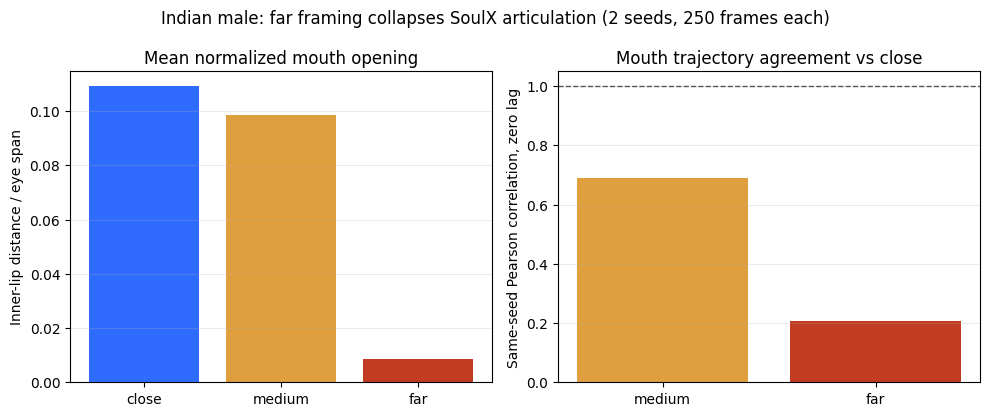

In [3]:
colors = ['#2F6BFF', '#E09F3E', '#C23B22']
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
axes[0].bar(order, summary.loc[order, 'mean_opening'], color=colors)
axes[0].set_title('Mean normalized mouth opening')
axes[0].set_ylabel('Inner-lip distance / eye span')
axes[0].grid(axis='y', alpha=.25)

corr = comparisons.groupby('distance')['zero_lag_correlation_vs_close'].mean().reindex(['medium', 'far'])
axes[1].bar(corr.index, corr.values, color=colors[1:])
axes[1].axhline(1, color='#555', lw=1, ls='--')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Mouth trajectory agreement vs close')
axes[1].set_ylabel('Same-seed Pearson correlation, zero lag')
axes[1].grid(axis='y', alpha=.25)
fig.suptitle('Indian male: far framing collapses SoulX articulation (2 seeds, 250 frames each)')
fig.tight_layout()
fig.savefig(evidence / 'indian-male-distance-effect.png', dpi=160, bbox_inches='tight')
plt.show()

The far clips retain 100% face detection but show near-flat mouth motion. This rules out missing landmark tracks as the explanation. The side-by-side contact sheets and videos independently show that the far mouth remains nearly closed during speech.

In [4]:
series = {(row['distance'], row['seed']): row['opening_series'] for row in motion['rows']}
def paired_corr(a, b):
    pairs = [(x, y) for x, y in zip(a, b) if x is not None and y is not None]
    return float(np.corrcoef(np.array(pairs).T)[0, 1])

cross_seed = pd.Series({distance: paired_corr(series[(distance, 50)], series[(distance, 51)]) for distance in order}, name='seed50_vs_seed51_zero_lag_correlation')
cross_seed.to_frame().round(3)

,seed50_vs_seed51_zero_lag_correlation
close,0.853
medium,0.563
far,0.520


## Takeaways

1. **Close framing is clearly best for this avatar.** It preserves the strongest, most repeatable articulation and the visually cleanest mouth/teeth behavior of the tested variants.
2. **Far framing fails the practical lip-motion gate.** Mean opening is down 92.2%, p95 opening is down 83.7%, and frame-to-frame motion is down 74.6% versus close.
3. **Medium is not equivalent to close.** Average opening falls only 9.8%, but motion becomes 26.3% more volatile and cross-seed consistency drops from 0.853 to 0.563; several frames show more exaggerated teeth/mouth shapes.
4. **The far phase result is incoherent rather than a fixed delay.** The two seeds prefer opposite ±80 ms shifts and remain weakly correlated, so there is no stable timing correction to apply.
5. For this 320-pixel-wide profile, treat roughly **133 px face width (close)** as the preferred framing and **67 px (far)** as unacceptable. More natural references are needed before establishing a general production threshold.
